# Meteorological Data Analysis

This notebook loads and analyzes meteorological data from the auxiliary data folder.

## 1. Import Required Libraries

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 2. Load Data

In [ ]:
# Load the meteorological data
# Note: CSV uses semicolon delimiter and comma as decimal separator (European format)
df_cleaned = pd.read_csv('/home/vinicius/Netmob2026/auxiliar_data/metereological_data_cleaned.csv', sep=';', decimal=',')

print("Dataset loaded successfully!")
print(f"Shape: {df_cleaned.shape}")

Dataset loaded successfully!
Shape: (744, 19)


## 3. Display Basic Information

In [ ]:
# Display first few rows
print("First 5 rows:")
df_cleaned.head()

First 5 rows:
         Date  Time (UTC)  Temp. Ins. (C)  Temp. Max. (C)  Temp. Min. (C)  \
0  01/03/2026           0            25.5            25.8            25.4   
1  01/03/2026         100            25.8            25.8            25.5   
2  01/03/2026         200            25.5            25.9            25.4   
3  01/03/2026         300            25.4            25.6            25.3   
4  01/03/2026         400            24.0            25.4            24.0   

   Umi. Ins. (%)  Umi. Max. (%)  Umi. Min. (%)  Pto Orvalho Ins. (C)  \
0            NaN            NaN            NaN                   NaN   
1            NaN            NaN            NaN                   NaN   
2            NaN            NaN            NaN                   NaN   
3            NaN            NaN            NaN                   NaN   
4            NaN            NaN            NaN                   NaN   

   Pto Orvalho Max. (C)  Pto Orvalho Min. (C)  Pressure Ins. (hPa)  \
0                   

## 4. Data Summary Statistics

In [62]:
# Display descriptive statistics
print("\nDescriptive Statistics:")
print(df_cleaned.describe())


Descriptive Statistics:
       Temp. Ins. (C)  Temp. Max. (C)  Temp. Min. (C)  Pressure Ins. (hPa)  \
count      708.000000      707.000000      707.000000           709.000000   
mean        26.220339       26.702970       25.765347          1012.544429   
std          2.774364        2.946007        2.600561             2.715355   
min         20.700000       20.800000       20.700000          1005.800000   
25%         24.300000       24.600000       23.900000          1010.800000   
50%         25.700000       26.100000       25.400000          1012.300000   
75%         28.000000       28.600000       27.300000          1014.100000   
max         34.500000       35.400000       34.000000          1020.000000   

       Pressure Max. (hPa)  Pressure Min. (hPa)  Wind Speed (m/s)  \
count           708.000000           708.000000        709.000000   
mean           1012.773446          1012.305932          1.361495   
std               2.704996             2.721052          0.926858

## 5. Temperature Analysis

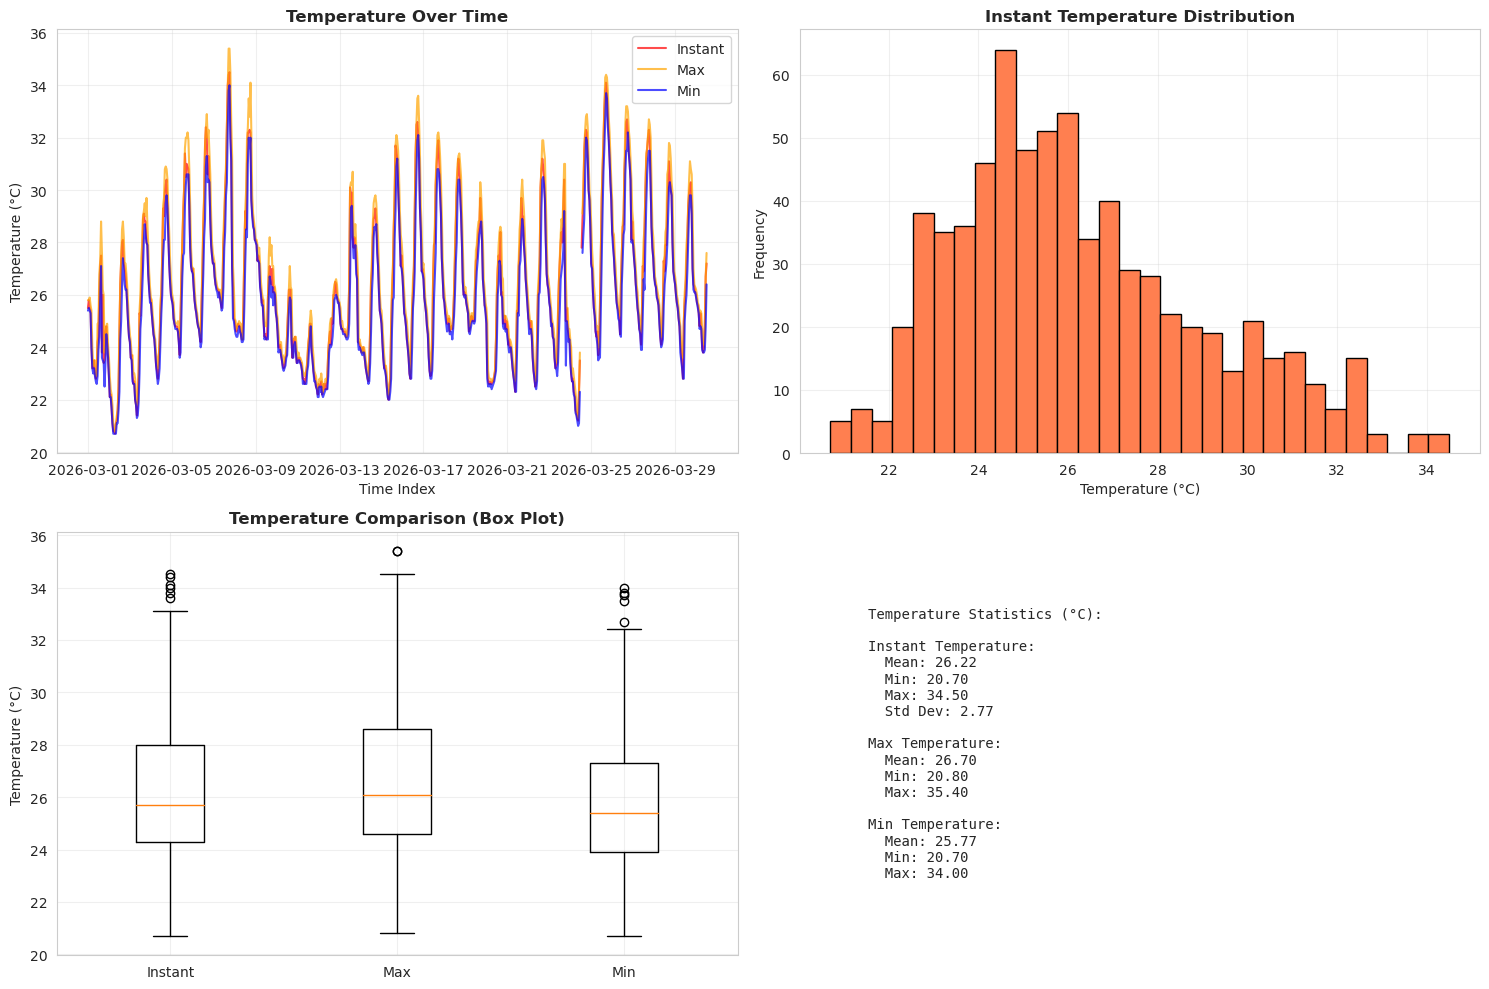

In [66]:
# Create a figure with temperature data
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Temperature variations
axes[0, 0].plot(df_cleaned['Temp. Ins. (C)'], label='Instant', color='red', alpha=0.7)
axes[0, 0].plot(df_cleaned['Temp. Max. (C)'], label='Max', color='orange', alpha=0.7)
axes[0, 0].plot(df_cleaned['Temp. Min. (C)'], label='Min', color='blue', alpha=0.7)
axes[0, 0].set_title('Temperature Over Time', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Time Index')
axes[0, 0].set_ylabel('Temperature (°C)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Temperature histogram
axes[0, 1].hist(df_cleaned['Temp. Ins. (C)'].dropna(), bins=30, color='coral', edgecolor='black')
axes[0, 1].set_title('Instant Temperature Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Temperature (°C)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# Box plot for temperature variations
temp_data = df_cleaned[['Temp. Ins. (C)', 'Temp. Max. (C)', 'Temp. Min. (C)']].dropna()
axes[1, 0].boxplot([temp_data['Temp. Ins. (C)'], temp_data['Temp. Max. (C)'], temp_data['Temp. Min. (C)']], 
                   labels=['Instant', 'Max', 'Min'])
axes[1, 0].set_title('Temperature Comparison (Box Plot)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Temperature (°C)')
axes[1, 0].grid(True, alpha=0.3)

# Temperature stats
axes[1, 1].axis('off')
temp_stats = f"""
Temperature Statistics (°C):

Instant Temperature:
  Mean: {df_cleaned['Temp. Ins. (C)'].mean():.2f}
  Min: {df_cleaned['Temp. Ins. (C)'].min():.2f}
  Max: {df_cleaned['Temp. Ins. (C)'].max():.2f}
  Std Dev: {df_cleaned['Temp. Ins. (C)'].std():.2f}

Max Temperature:
  Mean: {df_cleaned['Temp. Max. (C)'].mean():.2f}
  Min: {df_cleaned['Temp. Max. (C)'].min():.2f}
  Max: {df_cleaned['Temp. Max. (C)'].max():.2f}

Min Temperature:
  Mean: {df_cleaned['Temp. Min. (C)'].mean():.2f}
  Min: {df_cleaned['Temp. Min. (C)'].min():.2f}
  Max: {df_cleaned['Temp. Min. (C)'].max():.2f}
"""
axes[1, 1].text(0.1, 0.5, temp_stats, fontsize=10, family='monospace', verticalalignment='center')

plt.tight_layout()
plt.show()

## 6. Pressure Analysis

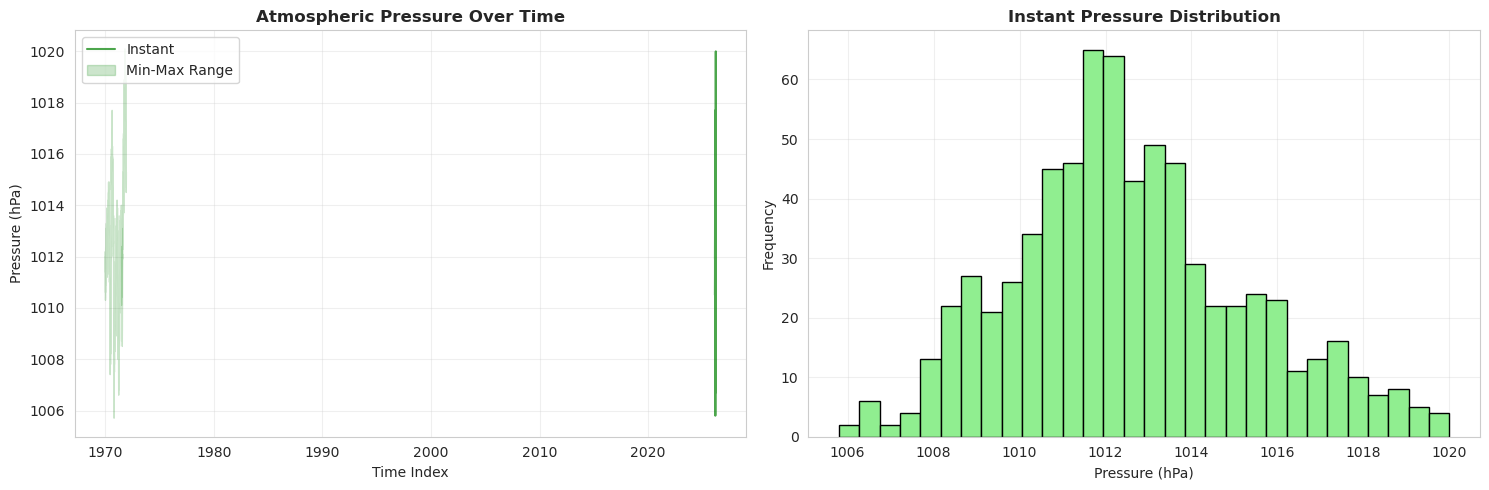

Pressure Statistics (hPa):
Mean: 1012.54
Min: 1005.80
Max: 1020.00
Std Dev: 2.72


In [67]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Pressure variations over time
axes[0].plot(df_cleaned['Pressure Ins. (hPa)'], label='Instant', color='green', alpha=0.7, linewidth=1.5)
axes[0].fill_between(range(len(df_cleaned)), df_cleaned['Pressure Min. (hPa)'], df_cleaned['Pressure Max. (hPa)'], 
                     alpha=0.2, color='green', label='Min-Max Range')
axes[0].set_title('Atmospheric Pressure Over Time', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Time Index')
axes[0].set_ylabel('Pressure (hPa)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Pressure distribution
axes[1].hist(df_cleaned['Pressure Ins. (hPa)'].dropna(), bins=30, color='lightgreen', edgecolor='black')
axes[1].set_title('Instant Pressure Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Pressure (hPa)')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Pressure Statistics (hPa):")
print(f"Mean: {df_cleaned['Pressure Ins. (hPa)'].mean():.2f}")
print(f"Min: {df_cleaned['Pressure Ins. (hPa)'].min():.2f}")
print(f"Max: {df_cleaned['Pressure Ins. (hPa)'].max():.2f}")
print(f"Std Dev: {df_cleaned['Pressure Ins. (hPa)'].std():.2f}")

## 7. Wind Analysis

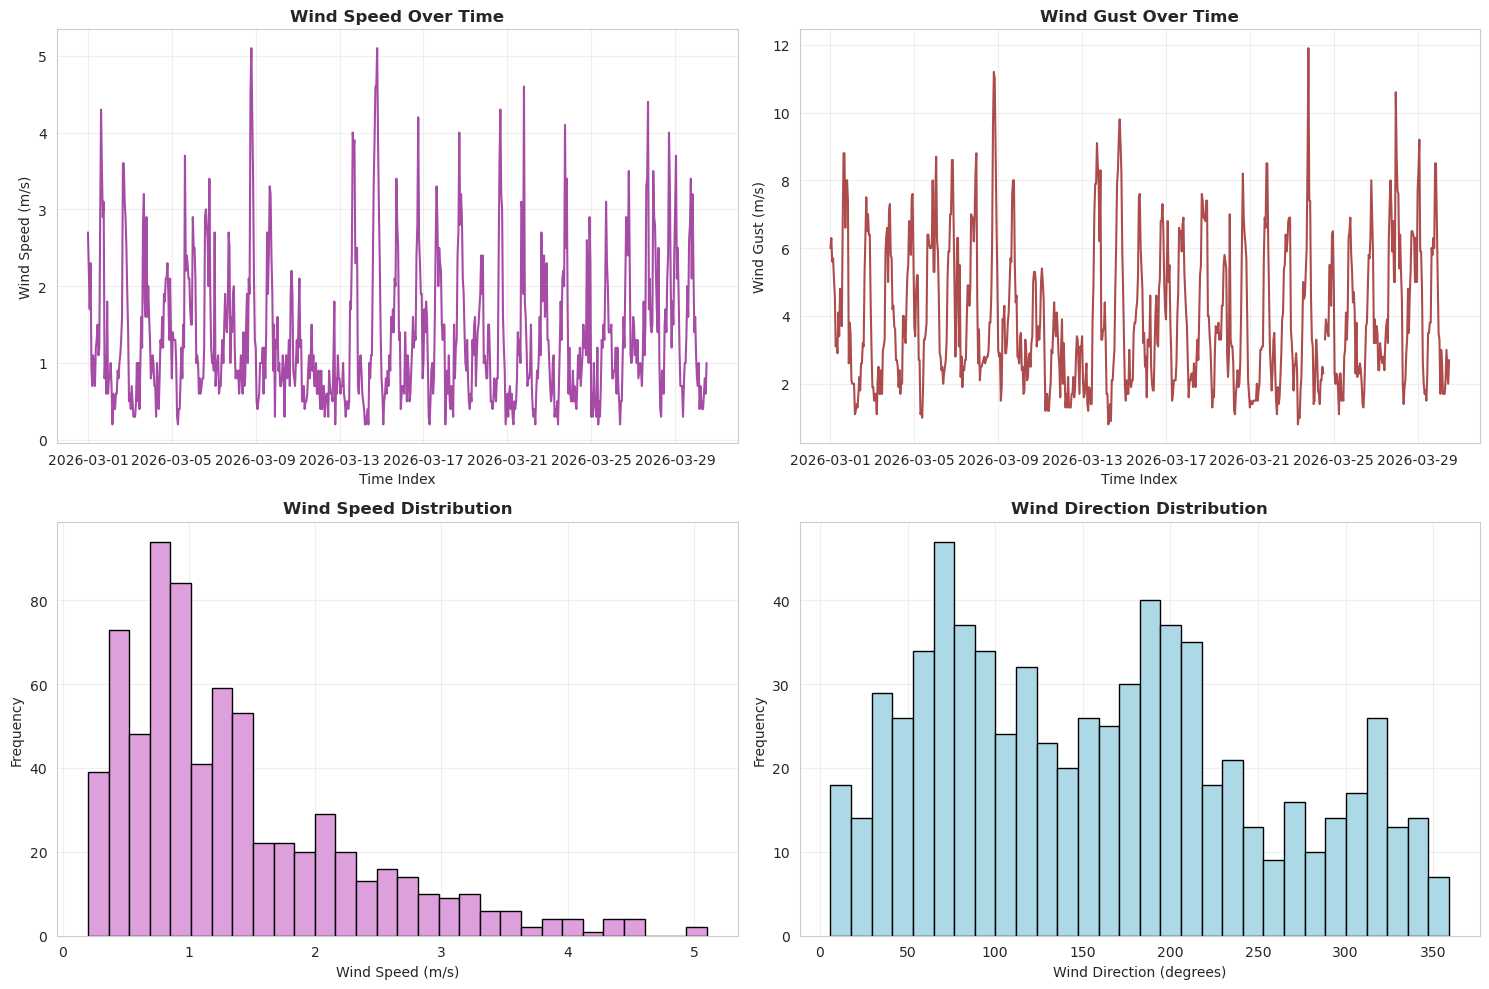

Wind Statistics:

Wind Speed (m/s):
  Mean: 1.36
  Min: 0.20
  Max: 5.10

Wind Gust (m/s):
  Mean: 3.97
  Min: 0.80
  Max: 11.90


In [68]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Wind speed over time
axes[0, 0].plot(df_cleaned['Wind Speed (m/s)'], color='purple', alpha=0.7, linewidth=1.5)
axes[0, 0].set_title('Wind Speed Over Time', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Time Index')
axes[0, 0].set_ylabel('Wind Speed (m/s)')
axes[0, 0].grid(True, alpha=0.3)

# Wind Gust over time
axes[0, 1].plot(df_cleaned['Raj. Vento (m/s)'], color='darkred', alpha=0.7, linewidth=1.5)
axes[0, 1].set_title('Wind Gust Over Time', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Time Index')
axes[0, 1].set_ylabel('Wind Gust (m/s)')
axes[0, 1].grid(True, alpha=0.3)

# Wind speed distribution
axes[1, 0].hist(df_cleaned['Wind Speed (m/s)'].dropna(), bins=30, color='plum', edgecolor='black')
axes[1, 0].set_title('Wind Speed Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Wind Speed (m/s)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)

# Wind direction distribution (circular-like)
axes[1, 1].hist(df_cleaned['Wind Dir. (m/s)'].dropna(), bins=30, color='lightblue', edgecolor='black')
axes[1, 1].set_title('Wind Direction Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Wind Direction (degrees)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Wind Statistics:")
print(f"\nWind Speed (m/s):")
print(f"  Mean: {df_cleaned['Wind Speed (m/s)'].mean():.2f}")
print(f"  Min: {df_cleaned['Wind Speed (m/s)'].min():.2f}")
print(f"  Max: {df_cleaned['Wind Speed (m/s)'].max():.2f}")
print(f"\nWind Gust (m/s):")
print(f"  Mean: {df_cleaned['Raj. Vento (m/s)'].mean():.2f}")
print(f"  Min: {df_cleaned['Raj. Vento (m/s)'].min():.2f}")
print(f"  Max: {df_cleaned['Raj. Vento (m/s)'].max():.2f}")

## 8. Radiation and Rainfall Analysis

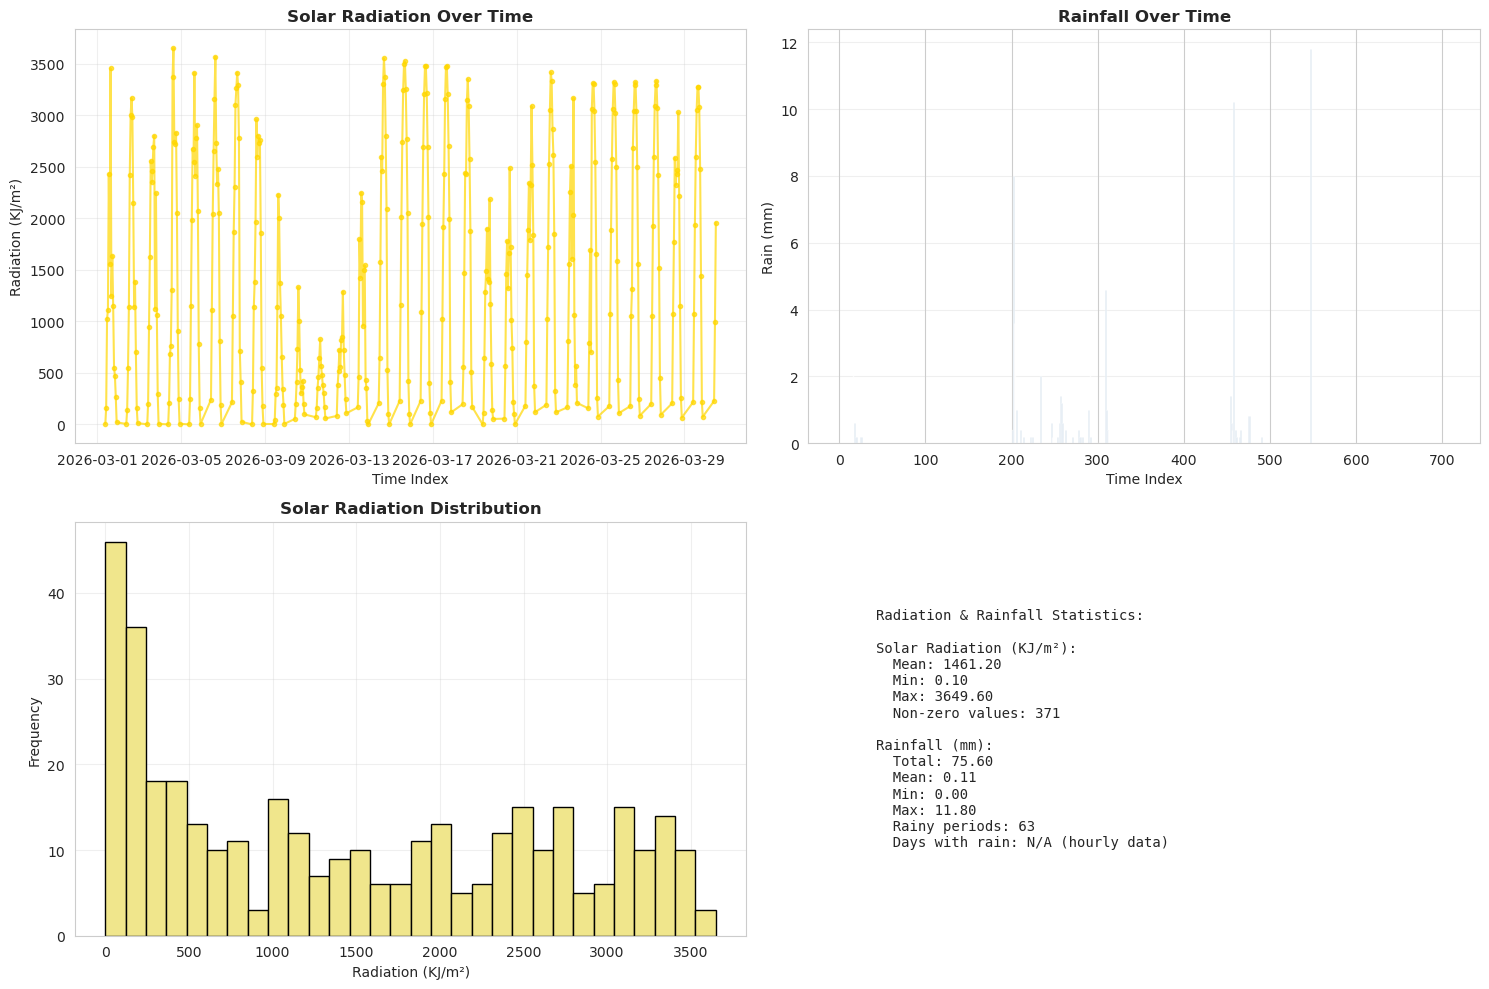

In [69]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Solar radiation over time
axes[0, 0].plot(df_cleaned['Radiation (KJ/m²)'].dropna(), color='gold', alpha=0.7, linewidth=1.5, marker='o', markersize=3)
axes[0, 0].set_title('Solar Radiation Over Time', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Time Index')
axes[0, 0].set_ylabel('Radiation (KJ/m²)')
axes[0, 0].grid(True, alpha=0.3)

# Rainfall over time
axes[0, 1].bar(range(len(df_cleaned)), df_cleaned['Rain (mm)'], color='steelblue', alpha=0.7, width=0.8)
axes[0, 1].set_title('Rainfall Over Time', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Time Index')
axes[0, 1].set_ylabel('Rain (mm)')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Radiation distribution
axes[1, 0].hist(df_cleaned['Radiation (KJ/m²)'].dropna(), bins=30, color='khaki', edgecolor='black')
axes[1, 0].set_title('Solar Radiation Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Radiation (KJ/m²)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)

# Rainfall statistics
axes[1, 1].axis('off')
rain_stats = f"""
Radiation & Rainfall Statistics:

Solar Radiation (KJ/m²):
  Mean: {df_cleaned['Radiation (KJ/m²)'].mean():.2f}
  Min: {df_cleaned['Radiation (KJ/m²)'].min():.2f}
  Max: {df_cleaned['Radiation (KJ/m²)'].max():.2f}
  Non-zero values: {(df_cleaned['Radiation (KJ/m²)'] > 0).sum()}

Rainfall (mm):
  Total: {df_cleaned['Rain (mm)'].sum():.2f}
  Mean: {df_cleaned['Rain (mm)'].mean():.2f}
  Min: {df_cleaned['Rain (mm)'].min():.2f}
  Max: {df_cleaned['Rain (mm)'].max():.2f}
  Rainy periods: {(df_cleaned['Rain (mm)'] > 0).sum()}
  Days with rain: N/A (hourly data)
"""
axes[1, 1].text(0.1, 0.5, rain_stats, fontsize=10, family='monospace', verticalalignment='center')

plt.tight_layout()
plt.show()

## 9. Correlation Matrix

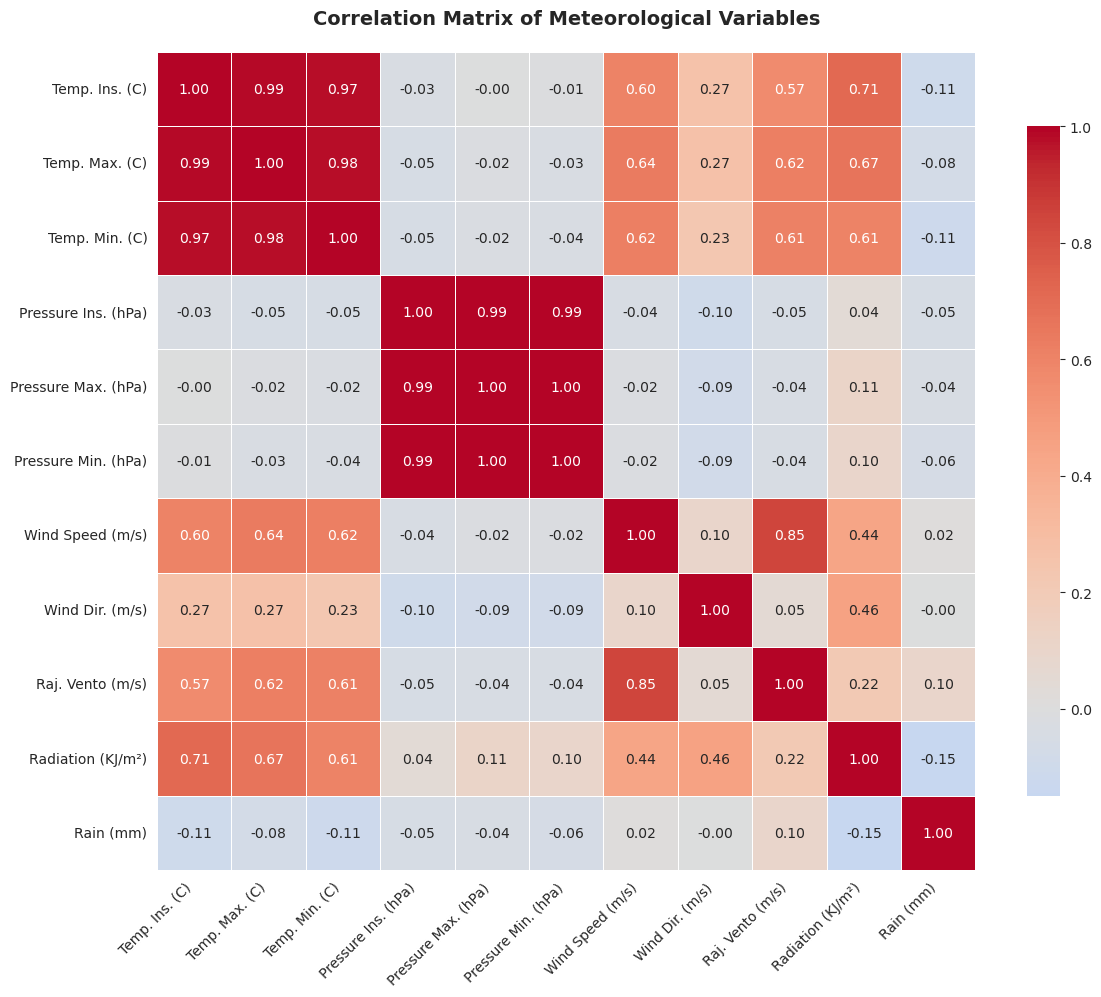

In [70]:
# Calculate correlation matrix for numeric columns
numeric_df = df_cleaned.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Meteorological Variables', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Rain Report Over Time

Daily Rainfall Summary - MARCH (Days 1-31):
    Day of Month  Daily Rainfall (mm)
0              1                  4.2
1              2                  0.6
2              3                  0.0
3              4                  0.0
4              5                  0.0
5              6                  0.0
6              7                  0.2
7              8                  1.4
8              9                 17.6
9             10                  2.8
10            11                  5.6
11            12                  1.6
12            13                 11.0
13            14                  0.4
14            15                  0.0
15            16                  0.0
16            17                  0.0
17            18                  0.0
18            19                  2.0
19            20                 16.2
20            21                  0.2
21            22                  0.0
22            23                 11.8
23            24                  0.0
24    

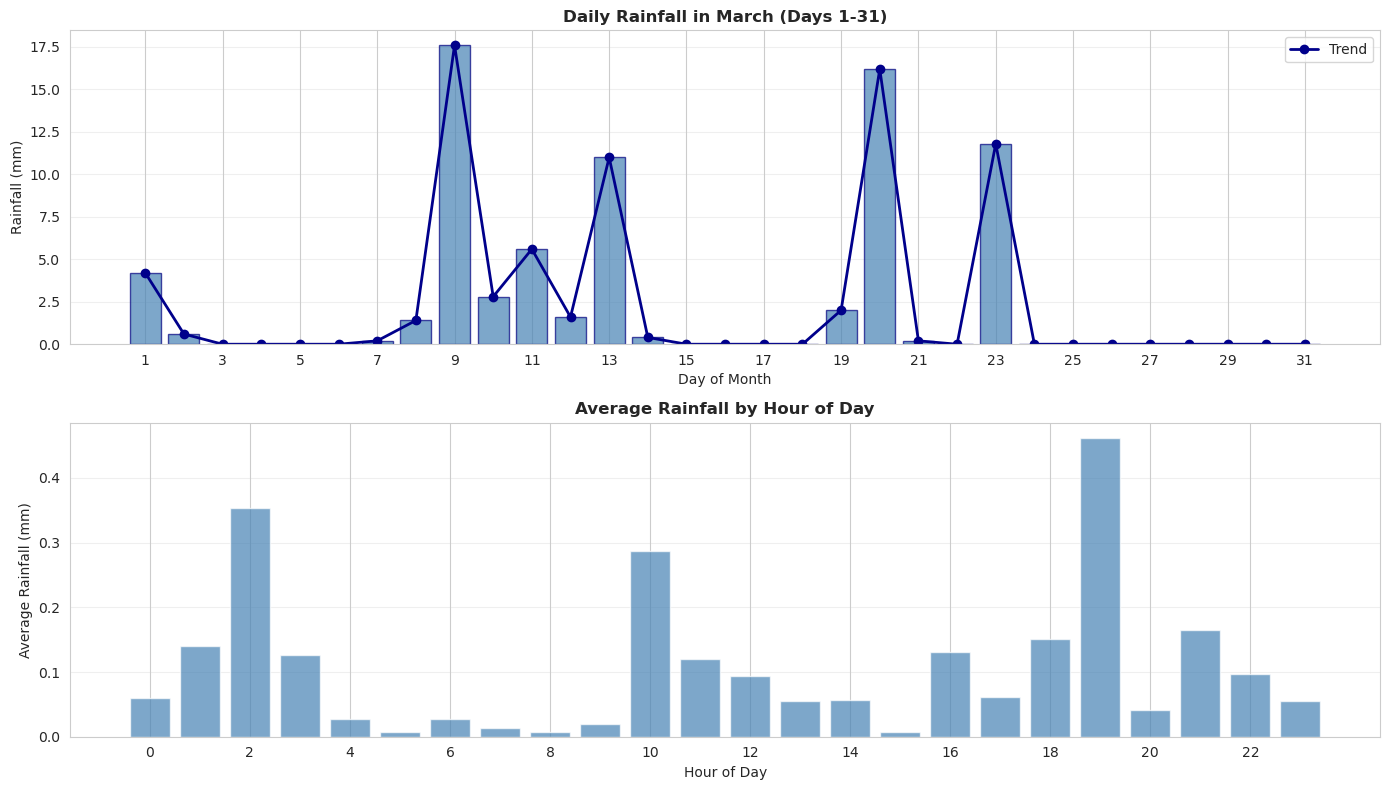

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for March only (month 3)
df_march = df_cleaned[df_cleaned.index.month == 3]

# Daily rainfall totals by day of month (1-31) for March
daily_rain_march = df_march.groupby(df_march.index.day)['Rain (mm)'].sum().reset_index()
daily_rain_march.columns = ['Day of Month', 'Daily Rainfall (mm)']

# Ensure all days 1-31 are represented
all_days = pd.DataFrame({'Day of Month': range(1, 32)})
daily_rain_march = all_days.merge(daily_rain_march, on='Day of Month', how='left')
daily_rain_march['Daily Rainfall (mm)'] = daily_rain_march['Daily Rainfall (mm)'].fillna(0)

print("Daily Rainfall Summary - MARCH (Days 1-31):")
print(daily_rain_march)
print(f"\nTotal Rainfall in March: {daily_rain_march['Daily Rainfall (mm)'].sum():.2f} mm")
print(f"Average Daily Rainfall: {daily_rain_march['Daily Rainfall (mm)'].mean():.2f} mm")
print(f"Max Daily Rainfall: {daily_rain_march['Daily Rainfall (mm)'].max():.2f} mm")
print(f"Days with Rain (>0): {(daily_rain_march['Daily Rainfall (mm)'] > 0).sum()}")

# Hourly rainfall distribution
hourly_rain = df_cleaned.groupby(df_cleaned.index.hour)['Rain (mm)'].mean().reset_index()
hourly_rain.columns = ['Hour', 'Average Rainfall (mm)']

print("\n\nHourly Rainfall Distribution:")
print(hourly_rain)

# Visualize daily rainfall trend for March (days 1-31)
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Daily rainfall trend for March days 1-31
axes[0].bar(daily_rain_march['Day of Month'], daily_rain_march['Daily Rainfall (mm)'], color='steelblue', alpha=0.7, edgecolor='navy')
axes[0].plot(daily_rain_march['Day of Month'], daily_rain_march['Daily Rainfall (mm)'], marker='o', linewidth=2, markersize=6, color='darkblue', label='Trend')
axes[0].set_title('Daily Rainfall in March (Days 1-31)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Day of Month')
axes[0].set_ylabel('Rainfall (mm)')
axes[0].set_xticks(range(1, 32, 2))
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].legend()

# Hourly rainfall distribution
axes[1].bar(hourly_rain['Hour'], hourly_rain['Average Rainfall (mm)'], color='steelblue', alpha=0.7)
axes[1].set_title('Average Rainfall by Hour of Day', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Average Rainfall (mm)')
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## 10. Summary Report

In [71]:
print("="*60)
print("METEOROLOGICAL DATA SUMMARY REPORT")
print("="*60)
print(f"\nDataset Shape: {df_cleaned.shape}")
print(f"Total Records: {len(df_cleaned)}")
print(f"\nData Quality:")
print(f"  Complete records: {df_cleaned.dropna().shape[0]}")
print(f"  Records with missing values: {len(df_cleaned) - df_cleaned.dropna().shape[0]}")
print(f"\nKey Variables:")
print(f"  1. Temperature (°C): {df_cleaned['Temp. Ins. (C)'].mean():.1f}°C mean")
print(f"  2. Pressure (hPa): {df_cleaned['Pressure Ins. (hPa)'].mean():.1f} mean")
print(f"  3. Wind Speed (m/s): {df_cleaned['Wind Speed (m/s)'].mean():.2f} m/s mean")
print(f"  4. Wind Gust (m/s): {df_cleaned['Raj. Vento (m/s)'].mean():.2f} m/s mean")
print(f"  5. Solar Radiation (KJ/m²): {df_cleaned['Radiation (KJ/m²)'].sum():.0f} cumulative")
print(f"  6. Rainfall (mm): {df_cleaned['Rain (mm)'].sum():.1f}mm total")
print("\n" + "="*60)

METEOROLOGICAL DATA SUMMARY REPORT

Dataset Shape: (744, 11)
Total Records: 744

Data Quality:
  Complete records: 368
  Records with missing values: 376

Key Variables:
  1. Temperature (°C): 26.2°C mean
  2. Pressure (hPa): 1012.5 mean
  3. Wind Speed (m/s): 1.36 m/s mean
  4. Wind Gust (m/s): 3.97 m/s mean
  5. Solar Radiation (KJ/m²): 542104 cumulative
  6. Rainfall (mm): 75.6mm total

